<a href="https://www.kaggle.com/code/sonawanelalitsunil/cricket-ipl-2025-stats-predictions-ml-99-46?scriptVersionId=229106493" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/ipl-2025-player-lifetime-statistics/cricket_data_2025.csv


## Import dataset

In [2]:
df = pd.read_csv('/kaggle/input/ipl-2025-player-lifetime-statistics/cricket_data_2025.csv')

In [3]:
df.head()

,Year,Player_Name,Matches_Batted,Not_Outs,Runs_Scored,Highest_Score,Batting_Average,Balls_Faced,Batting_Strike_Rate,Centuries,...,Matches_Bowled,Balls_Bowled,Runs_Conceded,Wickets_Taken,Best_Bowling_Match,Bowling_Average,Economy_Rate,Bowling_Strike_Rate,Four_Wicket_Hauls,Five_Wicket_Hauls
0,NaN,Aaron Hardie,No stats,No stats,No stats,No stats,No stats,No stats,No stats,No stats,...,No stats,No stats,No stats,No stats,No stats,No stats,No stats,No stats,No stats,No stats
1,2024.0,Abdul Samad,16,2,182,37*,18.2,108,168.52,0,...,16,0,0,0,0,0,0,0,0,0
2,2023.0,Abdul Samad,9,4,169,37*,42.25,128,132.03,0,...,9,0,0,0,0,0,0,0,0,0
3,2022.0,Abdul Samad,2,0,4,4,2.0,7,57.14,0,...,2,6,8,0,0/8,0,8.00,0,0,0
4,2021.0,Abdul Samad,11,1,111,28,12.33,87,127.58,0,...,11,6,9,1,1/9,9.00,9.00,6.00,0,0


In [4]:
df.tail()

,Year,Player_Name,Matches_Batted,Not_Outs,Runs_Scored,Highest_Score,Batting_Average,Balls_Faced,Batting_Strike_Rate,Centuries,...,Matches_Bowled,Balls_Bowled,Runs_Conceded,Wickets_Taken,Best_Bowling_Match,Bowling_Average,Economy_Rate,Bowling_Strike_Rate,Four_Wicket_Hauls,Five_Wicket_Hauls
1003,2016.0,Yuzvendra Chahal,13,0,0,0,0.00,0.0,0.00,0,...,13,295,401,21,4/25,19.09,8.15,14.04,1,0
1004,2015.0,Yuzvendra Chahal,15,2,1,1*,0.00,1.0,100.00,0,...,15,281,415,23,3/40,18.04,8.86,12.21,0,0
1005,2014.0,Yuzvendra Chahal,14,2,1,1*,0.00,1.0,100.00,0,...,14,330,386,12,2/17,32.16,7.01,27.50,0,0
1006,2013.0,Yuzvendra Chahal,1,0,0,0,0.00,0.0,0.00,0,...,1,24,34,0,0/34,0,8.5,0,0,0
1007,NaN,Zeeshan Ansari,No stats,No stats,No stats,No stats,No stats,No stats,No stats,No stats,...,No stats,No stats,No stats,No stats,No stats,No stats,No stats,No stats,No stats,No stats


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1008 entries, 0 to 1007
Data columns (total 25 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Year                 957 non-null    float64
 1   Player_Name          1008 non-null   object 
 2   Matches_Batted       1008 non-null   object 
 3   Not_Outs             1008 non-null   object 
 4   Runs_Scored          1008 non-null   object 
 5   Highest_Score        1008 non-null   object 
 6   Batting_Average      1008 non-null   object 
 7   Balls_Faced          1008 non-null   object 
 8   Batting_Strike_Rate  1008 non-null   object 
 9   Centuries            1008 non-null   object 
 10  Half_Centuries       1008 non-null   object 
 11  Fours                1008 non-null   object 
 12  Sixes                1008 non-null   object 
 13  Catches_Taken        1008 non-null   object 
 14  Stumpings            1008 non-null   object 
 15  Matches_Bowled       1008 non-null   o

In [6]:
df.corr

<bound method DataFrame.corr of         Year       Player_Name Matches_Batted  Not_Outs Runs_Scored  \
0        NaN      Aaron Hardie       No stats  No stats    No stats   
1     2024.0       Abdul Samad             16         2         182   
2     2023.0       Abdul Samad              9         4         169   
3     2022.0       Abdul Samad              2         0           4   
4     2021.0       Abdul Samad             11         1         111   
...      ...               ...            ...       ...         ...   
1003  2016.0  Yuzvendra Chahal             13         0           0   
1004  2015.0  Yuzvendra Chahal             15         2           1   
1005  2014.0  Yuzvendra Chahal             14         2           1   
1006  2013.0  Yuzvendra Chahal              1         0           0   
1007     NaN    Zeeshan Ansari       No stats  No stats    No stats   

     Highest_Score Batting_Average Balls_Faced Batting_Strike_Rate Centuries  \
0         No stats        No stats 

In [7]:
df.describe()

,Year
count,957.000000
mean,2019.718913
std,3.798726
min,2008.000000
25%,2017.000000
50%,2021.000000
75%,2023.000000
max,2024.000000


In [8]:
df.isnull().sum()

Year                   51
Player_Name             0
Matches_Batted          0
Not_Outs                0
Runs_Scored             0
Highest_Score           0
Batting_Average         0
Balls_Faced             0
Batting_Strike_Rate     0
Centuries               0
Half_Centuries          0
Fours                   0
Sixes                   0
Catches_Taken           0
Stumpings               0
Matches_Bowled          0
Balls_Bowled            0
Runs_Conceded           0
Wickets_Taken           0
Best_Bowling_Match      0
Bowling_Average         0
Economy_Rate            0
Bowling_Strike_Rate     0
Four_Wicket_Hauls       0
Five_Wicket_Hauls       0
dtype: int64

In [9]:
df.duplicated().sum()

0

In [10]:
df.dtypes

Year                   float64
Player_Name             object
Matches_Batted          object
Not_Outs                object
Runs_Scored             object
Highest_Score           object
Batting_Average         object
Balls_Faced             object
Batting_Strike_Rate     object
Centuries               object
Half_Centuries          object
Fours                   object
Sixes                   object
Catches_Taken           object
Stumpings               object
Matches_Bowled          object
Balls_Bowled            object
Runs_Conceded           object
Wickets_Taken           object
Best_Bowling_Match      object
Bowling_Average         object
Economy_Rate            object
Bowling_Strike_Rate     object
Four_Wicket_Hauls       object
Five_Wicket_Hauls       object
dtype: object

In [11]:
df.shape

(1008, 25)

In [12]:
df.columns

Index(['Year', 'Player_Name', 'Matches_Batted', 'Not_Outs', 'Runs_Scored',
       'Highest_Score', 'Batting_Average', 'Balls_Faced',
       'Batting_Strike_Rate', 'Centuries', 'Half_Centuries', 'Fours', 'Sixes',
       'Catches_Taken', 'Stumpings', 'Matches_Bowled', 'Balls_Bowled',
       'Runs_Conceded', 'Wickets_Taken', 'Best_Bowling_Match',
       'Bowling_Average', 'Economy_Rate', 'Bowling_Strike_Rate',
       'Four_Wicket_Hauls', 'Five_Wicket_Hauls'],
      dtype='object')

## data visualizations

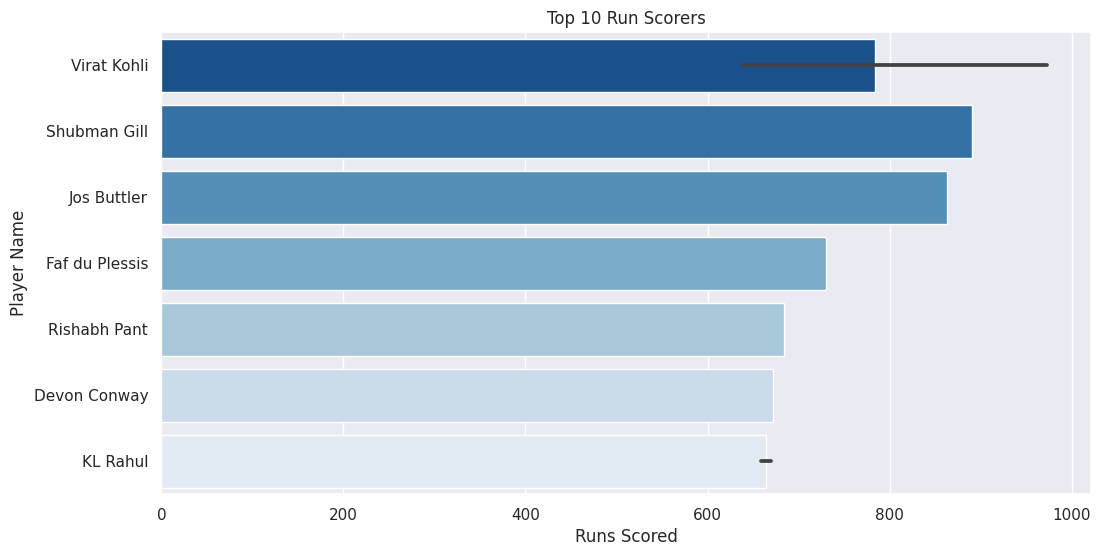

In [13]:
# Set the style
sns.set(style="darkgrid")
df['Runs_Scored'] = pd.to_numeric(df['Runs_Scored'], errors='coerce')
df['Wickets_Taken'] = pd.to_numeric(df['Wickets_Taken'], errors='coerce')

# 1. Top 10 Run Scorers
plt.figure(figsize=(12, 6))
top_run_scorers = df.nlargest(10, 'Runs_Scored')
sns.barplot(data=top_run_scorers, x='Runs_Scored', y='Player_Name', palette='Blues_r')
plt.xlabel("Runs Scored")
plt.ylabel("Player Name")
plt.title("Top 10 Run Scorers")
plt.show()

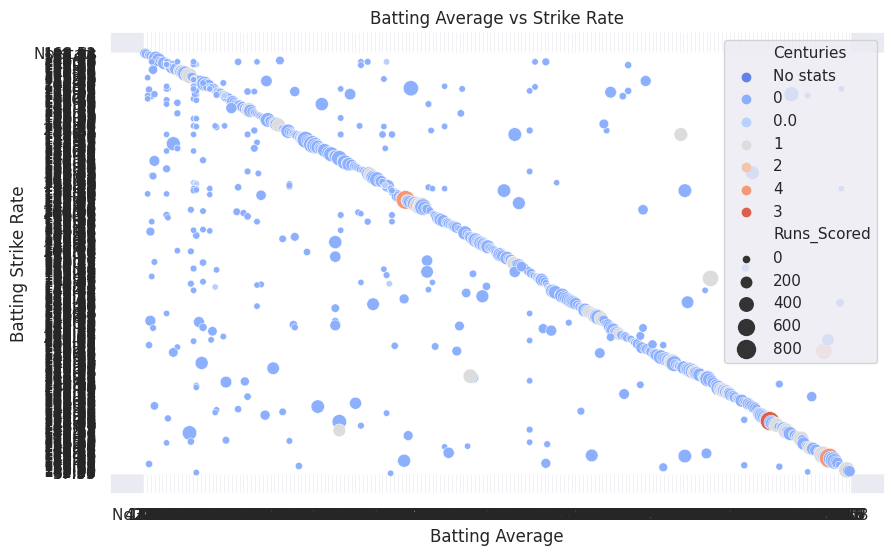

In [14]:
# 2. Batting Average vs Strike Rate
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Batting_Average', y='Batting_Strike_Rate', hue='Centuries', size='Runs_Scored', sizes=(20, 200), palette='coolwarm')
plt.xlabel("Batting Average")
plt.ylabel("Batting Strike Rate")
plt.title("Batting Average vs Strike Rate")
plt.legend()
plt.show()

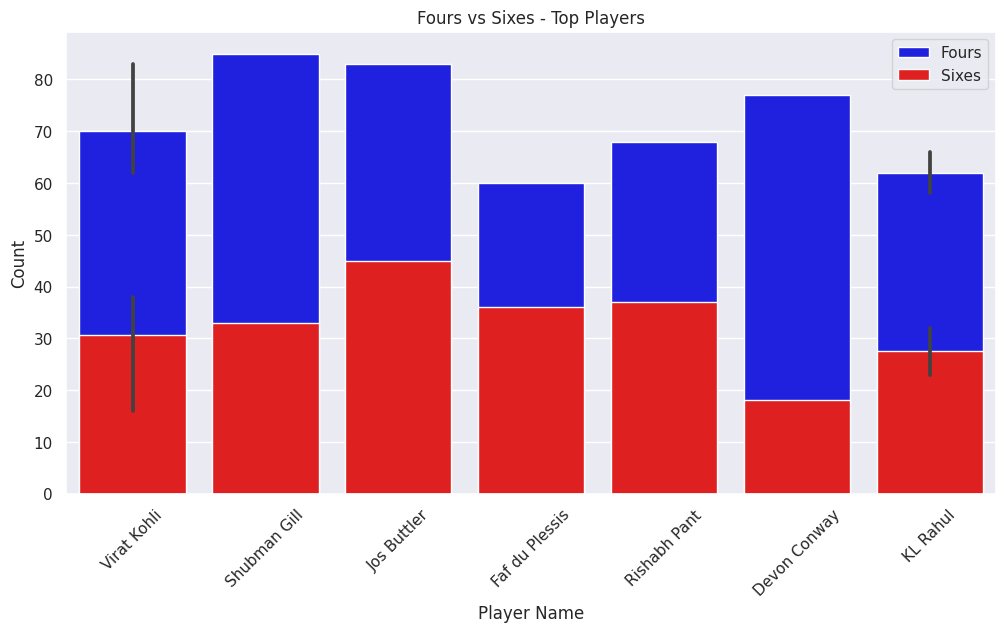

In [15]:
# Convert necessary columns to numeric
cols_to_convert = ['Runs_Scored', 'Wickets_Taken', 'Fours', 'Sixes', 'Batting_Average', 
                   'Batting_Strike_Rate', 'Balls_Faced', 'Centuries', 'Half_Centuries']
df[cols_to_convert] = df[cols_to_convert].apply(pd.to_numeric, errors='coerce')

# Drop NaN values to ensure calculations work
df = df.dropna(subset=['Runs_Scored', 'Wickets_Taken'])

# Define top_run_scorers again
top_run_scorers = df.nlargest(10, 'Runs_Scored')

# Now the barplot will work
plt.figure(figsize=(12, 6))
sns.barplot(data=top_run_scorers, x='Player_Name', y='Fours', color='blue', label='Fours')
sns.barplot(data=top_run_scorers, x='Player_Name', y='Sixes', color='red', label='Sixes')
plt.ylabel("Count")
plt.xlabel("Player Name")
plt.title("Fours vs Sixes - Top Players")
plt.legend()
plt.xticks(rotation=45)
plt.show()


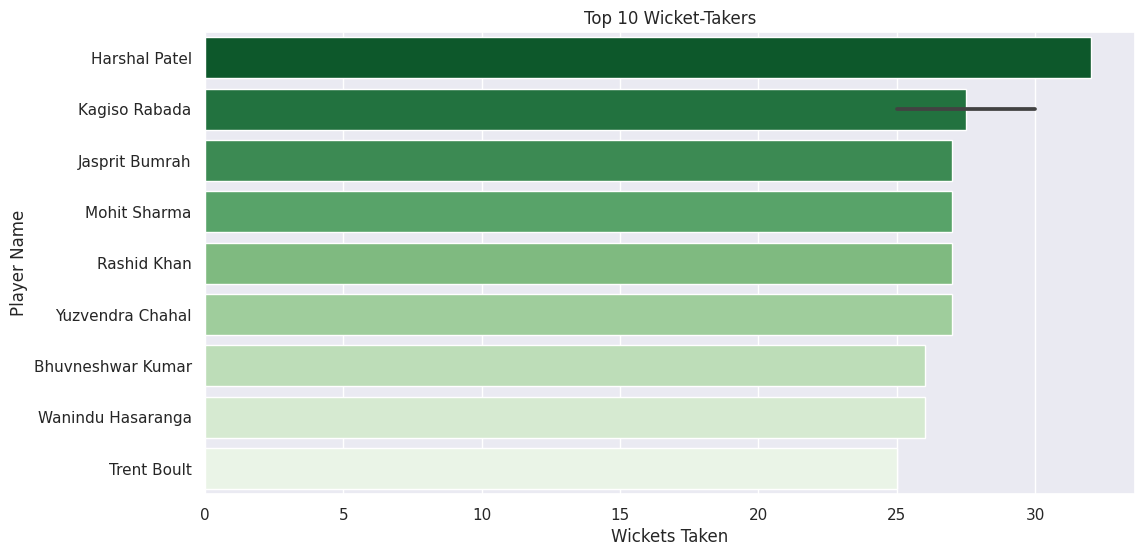

In [16]:
# 4. Top 10 Wicket-Takers
plt.figure(figsize=(12, 6))
top_wicket_takers = df.nlargest(10, 'Wickets_Taken')
sns.barplot(data=top_wicket_takers, x='Wickets_Taken', y='Player_Name', palette='Greens_r')
plt.xlabel("Wickets Taken")
plt.ylabel("Player Name")
plt.title("Top 10 Wicket-Takers")
plt.show()

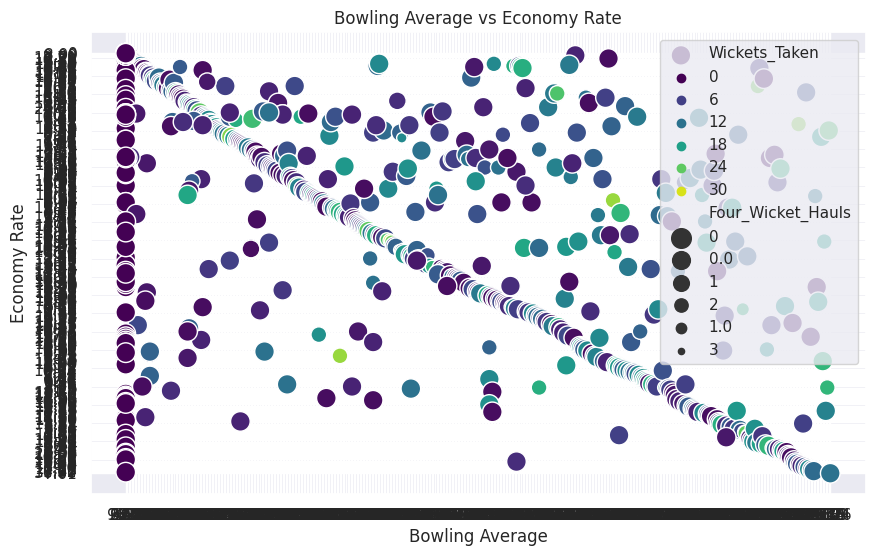

In [17]:

# 5. Bowling Average vs Economy Rate
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Bowling_Average', y='Economy_Rate', hue='Wickets_Taken', size='Four_Wicket_Hauls', sizes=(20, 200), palette='viridis')
plt.xlabel("Bowling Average")
plt.ylabel("Economy Rate")
plt.title("Bowling Average vs Economy Rate")
plt.legend()
plt.show()

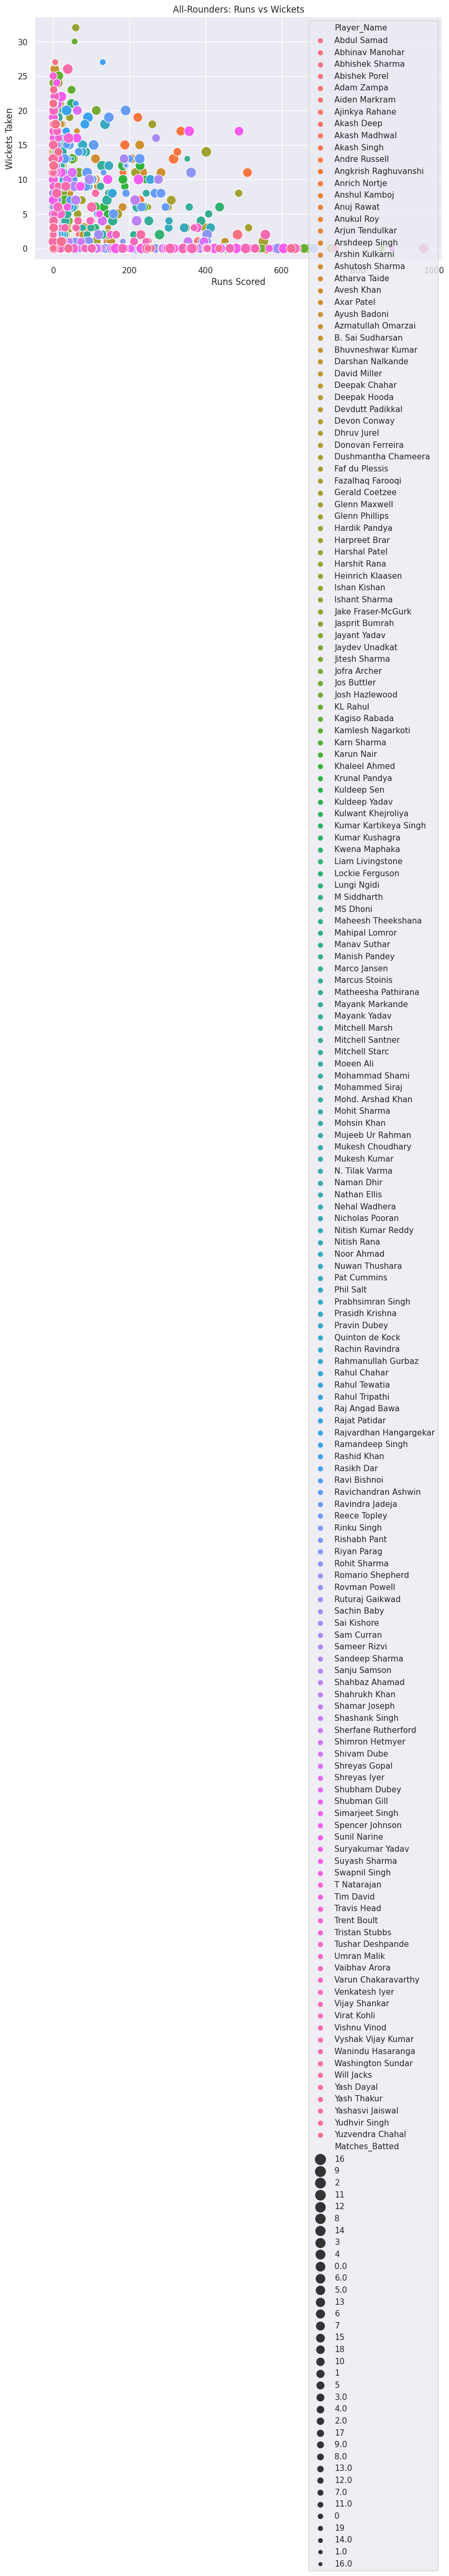

In [18]:
# 6. All-Rounders: Runs vs Wickets
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Runs_Scored', y='Wickets_Taken', size='Matches_Batted', hue='Player_Name', sizes=(20, 200))
plt.xlabel("Runs Scored")
plt.ylabel("Wickets Taken")
plt.title("All-Rounders: Runs vs Wickets")
plt.legend()
plt.show()

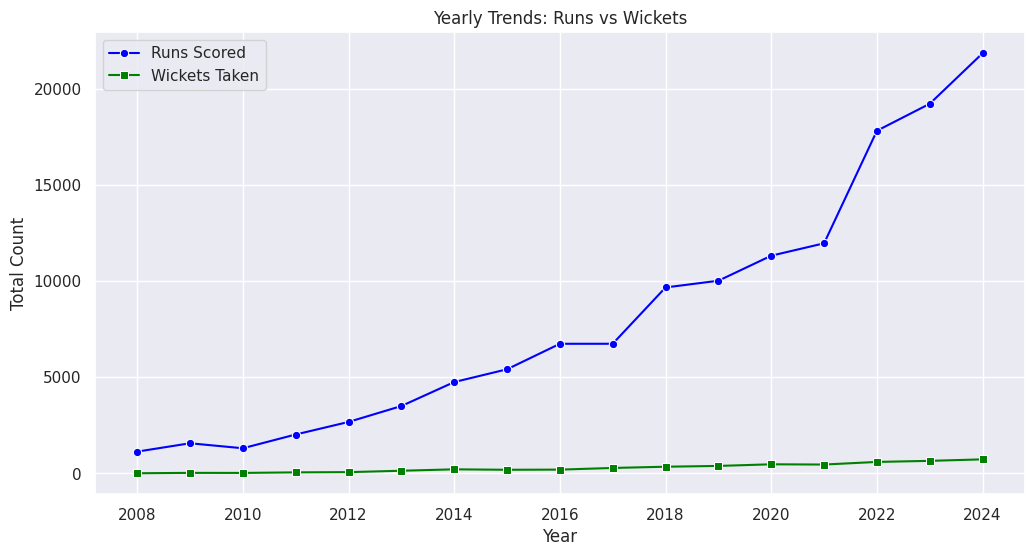

In [19]:

# 7. Yearly Trends of Runs and Wickets
plt.figure(figsize=(12, 6))
df_grouped = df.groupby("Year")[['Runs_Scored', 'Wickets_Taken']].sum().reset_index()
sns.lineplot(data=df_grouped, x='Year', y='Runs_Scored', marker='o', label='Runs Scored', color='blue')
sns.lineplot(data=df_grouped, x='Year', y='Wickets_Taken', marker='s', label='Wickets Taken', color='green')
plt.xlabel("Year")
plt.ylabel("Total Count")
plt.title("Yearly Trends: Runs vs Wickets")
plt.legend()
plt.show()

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.svm import SVR, SVC
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import GradientBoostingRegressor, GradientBoostingClassifier

In [21]:
# Convert numeric columns
numeric_cols = ['Matches_Batted', 'Not_Outs', 'Runs_Scored', 'Balls_Faced', 'Batting_Average', 
                'Batting_Strike_Rate', 'Centuries', 'Half_Centuries', 'Fours', 'Sixes', 'Catches_Taken',
                'Stumpings', 'Matches_Bowled', 'Balls_Bowled', 'Runs_Conceded', 'Wickets_Taken',
                'Bowling_Average', 'Economy_Rate', 'Bowling_Strike_Rate', 'Four_Wicket_Hauls', 'Five_Wicket_Hauls']

df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

# Encode categorical features
label_encoders = {}
categorical_cols = ['Player_Name', 'Year', 'Highest_Score', 'Best_Bowling_Match']

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le 

In [22]:
df = df.dropna()

In [23]:
# Define features and target
X = df.drop(columns=['Runs_Scored'])  # Features
y = df['Runs_Scored'] 

In [24]:
# Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [25]:
# Display shapes
print("Training Data Shape:", X_train.shape, y_train.shape)
print("Testing Data Shape:", X_test.shape, y_test.shape)

Training Data Shape: (765, 24) (765,)
Testing Data Shape: (192, 24) (192,)


In [26]:
# Convert Runs_Scored to categorical if needed (for classification)
if df['Runs_Scored'].nunique() <= 10:  # Example threshold
    y = pd.qcut(y, q=5, labels=False)  # Convert into 5 categories (adjust as needed)
    task_type = 'classification'
else:
    task_type = 'regression'

In [27]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [28]:
# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [29]:
# Define models
if task_type == 'classification':
    models = {
        "Logistic Regression": LogisticRegression(),
        "Decision Tree": DecisionTreeClassifier(),
        "Random Forest": RandomForestClassifier(),
        "K-Nearest Neighbors": KNeighborsClassifier(),
        "Naive Bayes": GaussianNB(),
        "Gradient Boosting": GradientBoostingClassifier(),
        "Support Vector Machine": SVC()
    }
else:
    models = {
        "Linear Regression": LinearRegression(),
        "Decision Tree": DecisionTreeRegressor(),
        "Random Forest": RandomForestRegressor(),
        "K-Nearest Neighbors": KNeighborsRegressor(),
        "Gradient Boosting": GradientBoostingRegressor(),
        "Support Vector Machine": SVR()
    }

In [30]:
# Train and evaluate models
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    if task_type == 'classification':
        accuracy = accuracy_score(y_test, y_pred) * 100
        results[name] = f"{accuracy:.2f}%"
    else:
        r2 = r2_score(y_test, y_pred) * 100  # R² in percentage
        results[name] = f"{r2:.2f}%"

# Display results
print("\nModel Performance:")
for model, score in results.items():
    print(f"{model}: {score}")


Model Performance:
Linear Regression: 99.72%
Decision Tree: 98.64%
Random Forest: 99.18%
K-Nearest Neighbors: 95.05%
Gradient Boosting: 99.46%
Support Vector Machine: 27.61%


## Thank you!!!...pls upvote!!!!!!